# **XAI Practice**

# **Customer Churn**

In [1]:
# Install required libraries (run once)
!pip install shap lime scikit-learn pandas numpy matplotlib seaborn --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
# Core data libraries
import numpy as np
import pandas as pd

In [4]:
# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [7]:
# Machine Learning
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [8]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import permutation_importance

In [9]:
# XAI Libraries
import shap
import lime
import lime.lime_tabular
from lime.lime_tabular import LimeTabularExplainer

In [10]:
# Settings
import warnings
warnings.filterwarnings('ignore')

# **Load Dataset**

In [11]:
csv_url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(csv_url)
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [12]:
print("Displaying the first 5 rows of the DataFrame:")
display(df.head())

print("\nDisplaying descriptive statistics of the DataFrame:")
display(df.describe(include='all'))

Displaying the first 5 rows of the DataFrame:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Displaying descriptive statistics of the DataFrame:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [13]:
print("Columns in the DataFrame:")
display(df.columns)

Columns in the DataFrame:


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

# Task
Analyze the customer churn dataset by checking data types and identifying missing values.

## Check Data Types and Missing Values

### Subtask:
Examine the data types of each column and identify any missing values in the DataFrame.


**Reasoning**:
The user wants to inspect the data types and check for missing values in the DataFrame, so I will use `df.info()` to display data types and `df.isnull().sum()` to show missing values.



In [14]:
print("Data types and non-null values:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessB

**Reasoning**:
The previous output showed that 'TotalCharges' is of 'object' dtype, which should be numeric. It's common for this column in this dataset to contain empty strings, which `isnull().sum()` doesn't catch. I need to convert it to a numeric type, coercing errors to NaN, and then recheck for missing values.



In [15]:
print("Data types and non-null values:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())

# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("\nMissing values after converting TotalCharges:")
print(df.isnull().sum())

Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessB

## Handle Missing Values

### Subtask:
Address any missing values found in the dataset, either by imputation or removal, based on the context.


**Reasoning**:
The subtask requires addressing missing values in the 'TotalCharges' column by filling them with the mean, and then verifying that all missing values have been handled. I will first calculate the mean of 'TotalCharges' and then use `fillna()` to impute the missing values, finally printing the sum of nulls for verification.



In [16]:
print("Missing values before imputation:")
print(df.isnull().sum())

# Calculate the mean of 'TotalCharges'
mean_total_charges = df['TotalCharges'].mean()

# Fill missing values in 'TotalCharges' with the mean
df['TotalCharges'].fillna(mean_total_charges, inplace=True)

print("\nMissing values after imputing TotalCharges with its mean:")
print(df.isnull().sum())

print("\nVerifying the data type of 'TotalCharges' after imputation:")
df.info()

Missing values before imputation:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Missing values after imputing TotalCharges with its mean:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges 

## Encode Categorical Features

### Subtask:
Convert categorical features into a numerical format suitable for machine learning models.


**Reasoning**:
I need to drop the 'customerID' column, identify and encode all remaining categorical columns (object dtype) including 'Churn' using `LabelEncoder`, and then verify the data types to ensure they are numerical.



In [17]:
print("Original DataFrame shape:", df.shape)
# 1. Drop the `customerID` column
df = df.drop('customerID', axis=1)
print("DataFrame shape after dropping customerID:", df.shape)

# 2. Identify all categorical columns (object dtype) excluding 'customerID' as it's already dropped
categorical_cols = df.select_dtypes(include='object').columns

# 3. Initialize a LabelEncoder
le = LabelEncoder()

print("\nEncoding categorical columns...")
# 4. For each categorical column, apply LabelEncoder
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
    print(f"  Encoded column: {col}")

# 5. Verify the data types of the DataFrame columns after encoding
print("\nData types after encoding categorical features:")
df.info()

Original DataFrame shape: (7043, 21)
DataFrame shape after dropping customerID: (7043, 20)

Encoding categorical columns...
  Encoded column: gender
  Encoded column: Partner
  Encoded column: Dependents
  Encoded column: PhoneService
  Encoded column: MultipleLines
  Encoded column: InternetService
  Encoded column: OnlineSecurity
  Encoded column: OnlineBackup
  Encoded column: DeviceProtection
  Encoded column: TechSupport
  Encoded column: StreamingTV
  Encoded column: StreamingMovies
  Encoded column: Contract
  Encoded column: PaperlessBilling
  Encoded column: PaymentMethod
  Encoded column: Churn

Data types after encoding categorical features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64

## Split Data

### Subtask:
Split the dataset into training and testing sets.


The previous steps have cleaned and encoded the dataset. Now, to prepare for model training, the dataset needs to be split into features (X) and the target variable (y). The target variable for this problem is 'Churn', while all other columns will serve as features for the model.

**Reasoning**:
I need to separate the features (X) from the target variable (y), split the dataset into training and testing sets, and then verify the shapes of the resulting sets, as per the subtask instructions.



In [18]:
print("Splitting data into features (X) and target (y)...")
# 1. Separate features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']
print("Features (X) and target (y) separated.")

print("\nSplitting data into training and testing sets...")
# 2. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data split into training and testing sets.")

print("\nVerifying the shapes of the resulting sets:")
# 3. Verify the shapes of the resulting training and testing sets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Splitting data into features (X) and target (y)...
Features (X) and target (y) separated.

Splitting data into training and testing sets...
Data split into training and testing sets.

Verifying the shapes of the resulting sets:
X_train shape: (5634, 19)
X_test shape: (1409, 19)
y_train shape: (5634,)
y_test shape: (1409,)


## Train Model

### Subtask:
Train a machine learning model (e.g., RandomForestClassifier) on the processed training data.


**Reasoning**:
I need to instantiate a RandomForestClassifier, train it with X_train and y_train, and then print a confirmation message as per the instructions.



In [19]:
print("Initializing and training RandomForestClassifier...")
# 1. Instantiate a RandomForestClassifier model
model = RandomForestClassifier(random_state=42)

# 2. Train the model using the fit method
model.fit(X_train, y_train)

# 3. Print a confirmation message
print("RandomForestClassifier model training complete.")

Initializing and training RandomForestClassifier...
RandomForestClassifier model training complete.


# Task
## Evaluate Model Performance

### Subtask:
Generate a classification report and calculate the ROC AUC score for the trained RandomForestClassifier model on the test set (`X_test`, `y_test`).

### Reasoning:
To evaluate the performance of the trained RandomForestClassifier model, I will use the `predict()` method to get class predictions and `predict_proba()` to get probability estimates on the `X_test` set. Then, I will generate a classification report using `sklearn.metrics.classification_report` to show precision, recall, f1-score, and support, and calculate the ROC AUC score using `sklearn.metrics.roc_auc_score` to measure the model's ability to distinguish between classes.

```python
# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Generate classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Calculate ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC AUC Score: {roc_auc:.4f}")
```

## Evaluate Model Performance

### Subtask:
Generate a classification report and calculate the ROC AUC score for the trained RandomForestClassifier model on the test set (`X_test`, `y_test`).


**Reasoning**:
I need to make predictions and probability estimates on the test set, then generate a classification report and calculate the ROC AUC score as per the instructions.



In [20]:
print("Generating predictions and evaluating model performance...")

# 1. Use the trained model to make predictions on the X_test set
y_pred = model.predict(X_test)

# 2. Use the trained model to get probability estimates for the positive class
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 3. Print a classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 4. Calculate the ROC AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC AUC Score: {roc_auc:.4f}")

Generating predictions and evaluating model performance...

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.65      0.47      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409


ROC AUC Score: 0.8364


## Explain Predictions with SHAP

### Subtask:
Utilize the SHAP library to explain the predictions of the RandomForestClassifier. This involves creating a SHAP explainer and calculating SHAP values for the test set. Visualize the summary plot to show overall feature importance and impact.


## Explain Predictions with SHAP

### Subtask:
Utilize the SHAP library to explain the predictions of the RandomForestClassifier. This involves creating a SHAP explainer and calculating SHAP values for the test set. Visualize the summary plot to show overall feature importance and impact.

### Reasoning:
To understand the feature importance and impact on the RandomForestClassifier's predictions, I will use SHAP (SHapley Additive exPlanations). I need to instantiate a `shap.TreeExplainer` for tree-based models like RandomForest, calculate the SHAP values for the `X_test` dataset, and then visualize these values using `shap.summary_plot` with both 'bar' and default 'dot' plot types to gain comprehensive insights into feature contributions.


**Reasoning**:
Following the explanation in the previous markdown cell, I will now generate the Python code to create a SHAP TreeExplainer, calculate SHAP values for the test set, and visualize the feature importance using two types of SHAP summary plots: 'bar' and 'dot'.



Creating SHAP TreeExplainer and calculating SHAP values...
Generating SHAP summary plots...

SHAP Summary Plot (Bar - Mean Absolute SHAP Value):


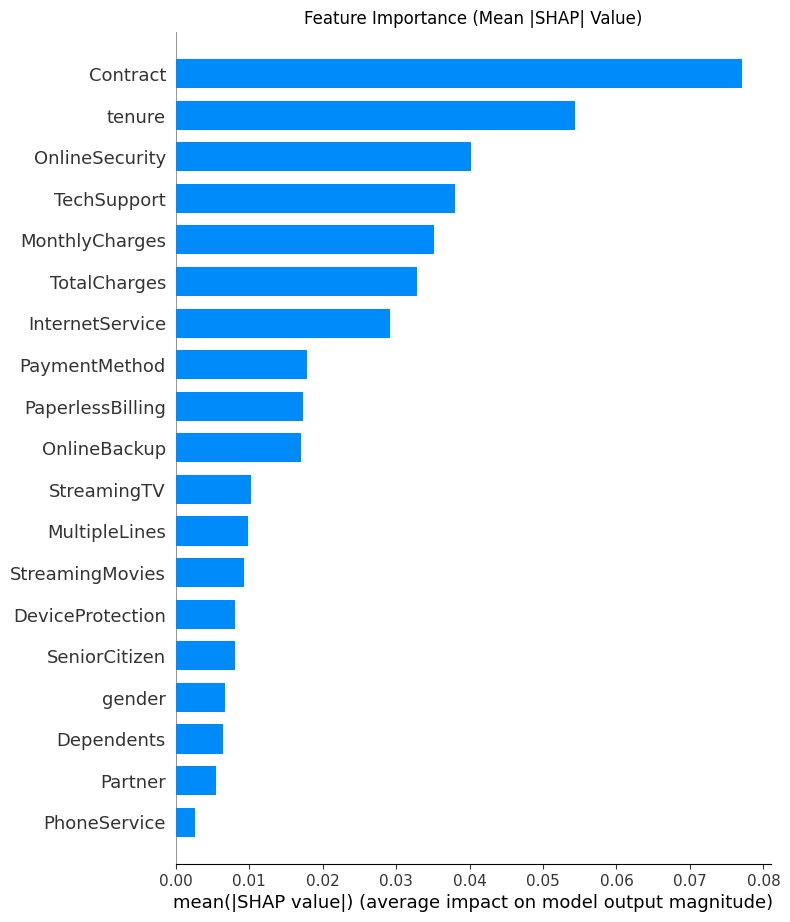


SHAP Summary Plot (Dot - Feature Impact and Direction):


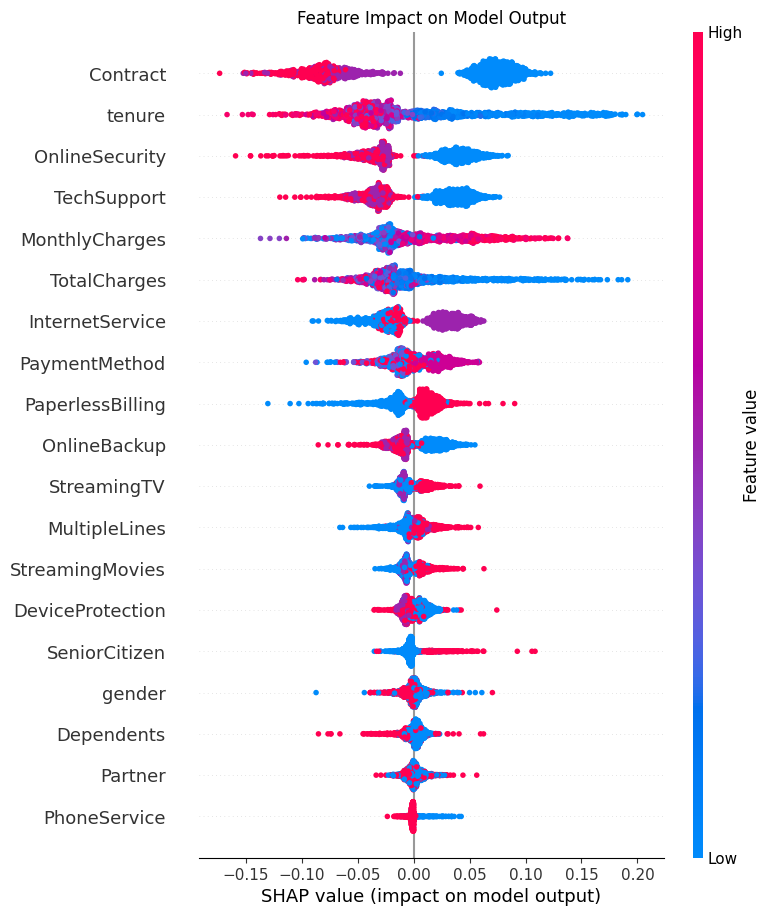

SHAP explanation complete.


In [22]:
print("Creating SHAP TreeExplainer and calculating SHAP values...")
# 1. Create a SHAP TreeExplainer object for the trained model
explainer = shap.TreeExplainer(model)

# 2. Calculate SHAP values for the X_test dataset
shap_values = explainer.shap_values(X_test)

print("Generating SHAP summary plots...")
# 3. Generate a SHAP summary plot (bar) for overall feature importance
print("\nSHAP Summary Plot (Bar - Mean Absolute SHAP Value):")
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar", show=False)
plt.title("Feature Importance (Mean |SHAP| Value)")
plt.show()

# 3. Generate a SHAP summary plot (dot) for detailed feature impact
print("\nSHAP Summary Plot (Dot - Feature Impact and Direction):")
shap.summary_plot(shap_values[:, :, 1], X_test, show=False)
plt.title("Feature Impact on Model Output")
plt.show()

print("SHAP explanation complete.")

## Explain Predictions with LIME

### Subtask:
Apply the LIME library to explain individual predictions of the RandomForestClassifier. Select a few instances from the test set and generate explanations for them, focusing on which features contribute to the prediction for each instance.


**Reasoning**:
I need to set up the LIME explainer by defining the prediction function, initializing LimeTabularExplainer, and then generating and displaying explanations for a few instances from the test set as requested in the subtask instructions.



In [23]:
print("Initializing LIME and generating explanations for individual instances...")

# 1. Define a predict_fn function for LIME
def predict_fn(data):
    # LIME expects probabilities for each class. Our model.predict_proba already returns this.
    # Ensure data is a DataFrame with the same columns as X_train for predict_proba
    data_df = pd.DataFrame(data, columns=X_train.columns)
    return model.predict_proba(data_df)

# 2. Create a LimeTabularExplainer instance
explainer = LimeTabularExplainer(
    training_data=X_train.values, # LIME expects a numpy array for training_data
    feature_names=X_train.columns.tolist(), # Feature names as a list
    class_names=['No Churn', 'Churn'], # Class names for the target variable
    mode='classification' # Specify classification task
)
print("LimeTabularExplainer initialized.")

# 3. Select a few instances from X_test to explain
# For demonstration, let's pick the first 3 instances from X_test
instances_to_explain_indices = [0, 1, 2]

print("\nGenerating explanations for selected instances...")
for i in instances_to_explain_indices:
    print(f"\n--- Explanation for instance {i} ---")
    instance_data = X_test.iloc[i].values # Get the numpy array for the instance
    true_label = y_test.iloc[i]

    # 4a. Use the explainer's explain_instance method
    # Specify num_features to limit the number of features in the explanation
    exp = explainer.explain_instance(
        data_row=instance_data,
        predict_fn=predict_fn,
        num_features=10 # Show top 10 features
    )

    # 4b. Print the explanation as text
    print("Predicted probabilities (No Churn, Churn):", predict_fn(instance_data.reshape(1, -1))[0])
    print(f"True label: {'Churn' if true_label == 1 else 'No Churn'}")
    print("LIME Explanation (as list of feature contributions):")
    print(exp.as_list())

    # 4c. Optionally, visualize the explanation in the notebook
    print("Displaying LIME explanation (HTML):")
    exp.show_in_notebook(show_table=True)

print("LIME explanation generation complete.")

Output hidden; open in https://colab.research.google.com to view.

## Analyze Permutation Importance

### Subtask:
Calculate and visualize the permutation importance of features for the RandomForestClassifier model.


**Reasoning**:
To analyze the permutation importance, I will use `sklearn.inspection.permutation_importance` to calculate feature importances on the test set, then sort these importances, and finally visualize them using a horizontal bar plot.



Calculating permutation importance...
Generating permutation importance plot...


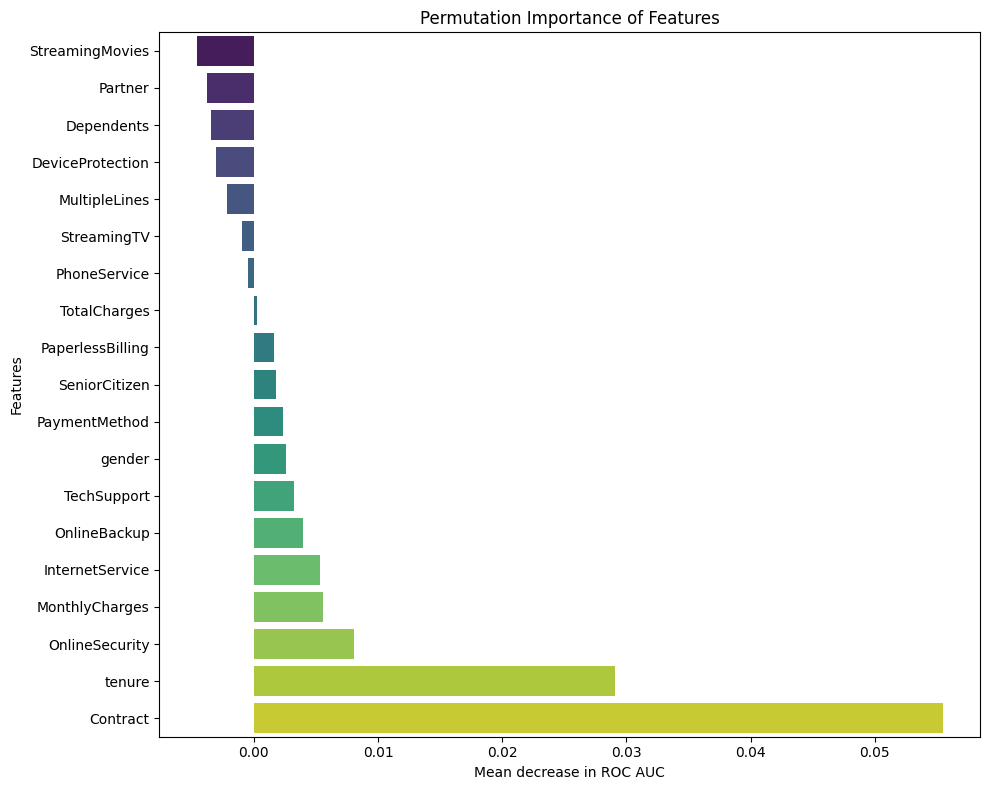

Permutation importance analysis complete.


In [24]:
print("Calculating permutation importance...")
# 1. Calculate the permutation importance
result = permutation_importance(
    model, X_test, y_test, scoring='roc_auc', n_repeats=10, random_state=42, n_jobs=-1
)

# 2. Store the results in a variable named `result` (already done above)

# 3. Create a pandas Series from the result.importances_mean and X_test.columns
feature_importances = pd.Series(result.importances_mean, index=X_test.columns)

# 4. Sort the feature importances in descending order
sorted_importances = feature_importances.sort_values(ascending=True)

print("Generating permutation importance plot...")
# 5. Create a horizontal bar plot to visualize the feature importances
plt.figure(figsize=(10, 8))
sns.barplot(x=sorted_importances.values, y=sorted_importances.index, palette='viridis')
plt.xlabel('Mean decrease in ROC AUC')
plt.ylabel('Features')
plt.title('Permutation Importance of Features')
plt.tight_layout()
plt.show()

print("Permutation importance analysis complete.")


Calculating Permutation Feature Importance...
             Feature  Importance
4             tenure    0.121707
17    MonthlyCharges    0.111697
14          Contract    0.106869
18      TotalCharges    0.083529
16     PaymentMethod    0.055396
8     OnlineSecurity    0.052325
15  PaperlessBilling    0.048349
11       TechSupport    0.046024
7    InternetService    0.037345
9       OnlineBackup    0.031292


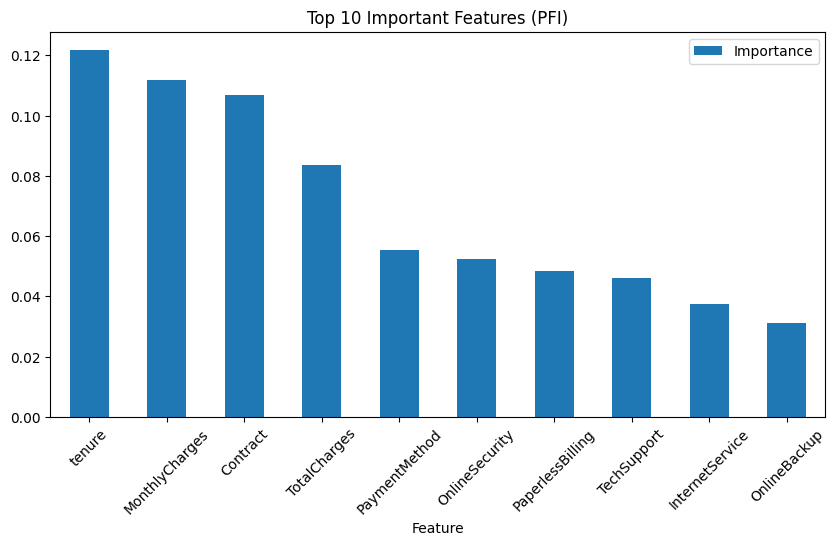

In [31]:
print("\nCalculating Permutation Feature Importance...")
result = permutation_importance( model, X_train, y_train, n_repeats=10, random_state=42 )
feature_names = X_train.columns

importance_df = pd.DataFrame({ "Feature": feature_names, "Importance": result.importances_mean }).sort_values(by="Importance", ascending=False)
print(importance_df.head(10))
importance_df.head(10).plot.bar(x="Feature", y="Importance", figsize=(10, 5))
plt.title("Top 10 Important Features (PFI)")
plt.xticks(rotation=45)
plt.show()

## Visualize Partial Dependence Plots (PDPs)

### Subtask:
Generate Partial Dependence Plots (PDPs) for selected key features to visualize the marginal effect of one or two features on the predicted outcome of the RandomForestClassifier. This will help understand the relationship between features and the target variable.


**Reasoning**:
To generate Partial Dependence Plots (PDPs), I will select key features based on previous importance analysis (like 'Contract', 'tenure', 'MonthlyCharges'), then use `PartialDependenceDisplay.from_estimator` to create single-feature and two-feature PDPs for the model, ensuring each plot is displayed with a descriptive title.



Generating Partial Dependence Plots...

Generating single-feature PDPs...


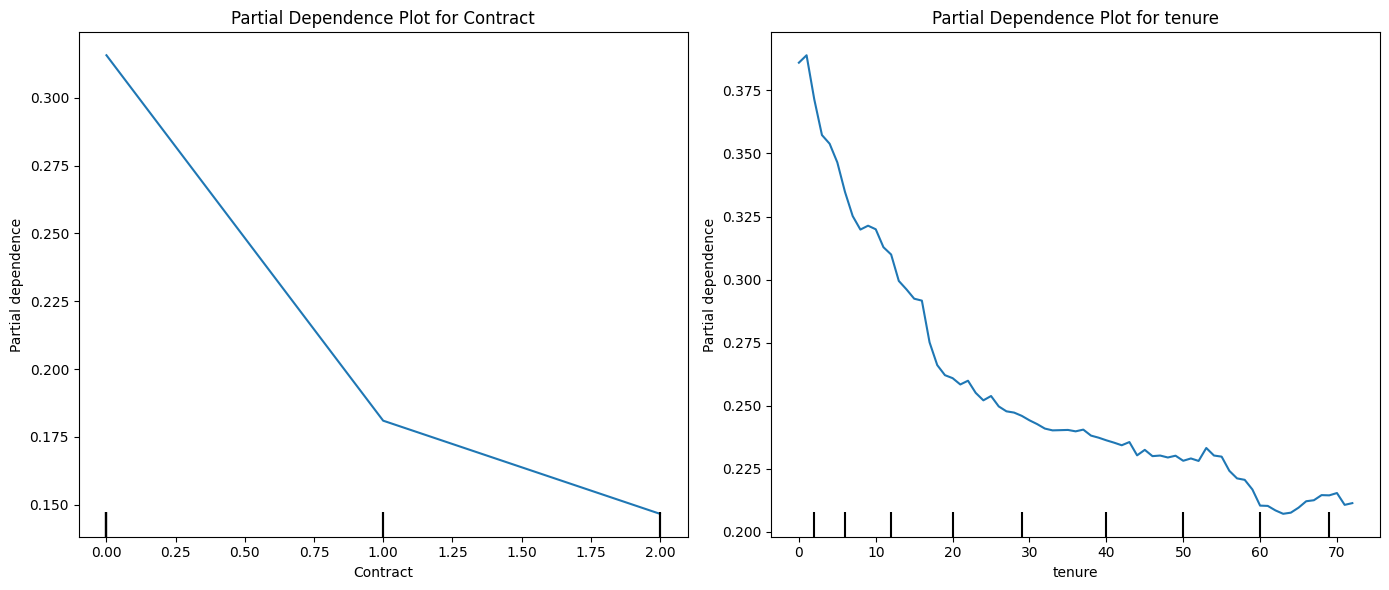


Generating two-feature PDP...


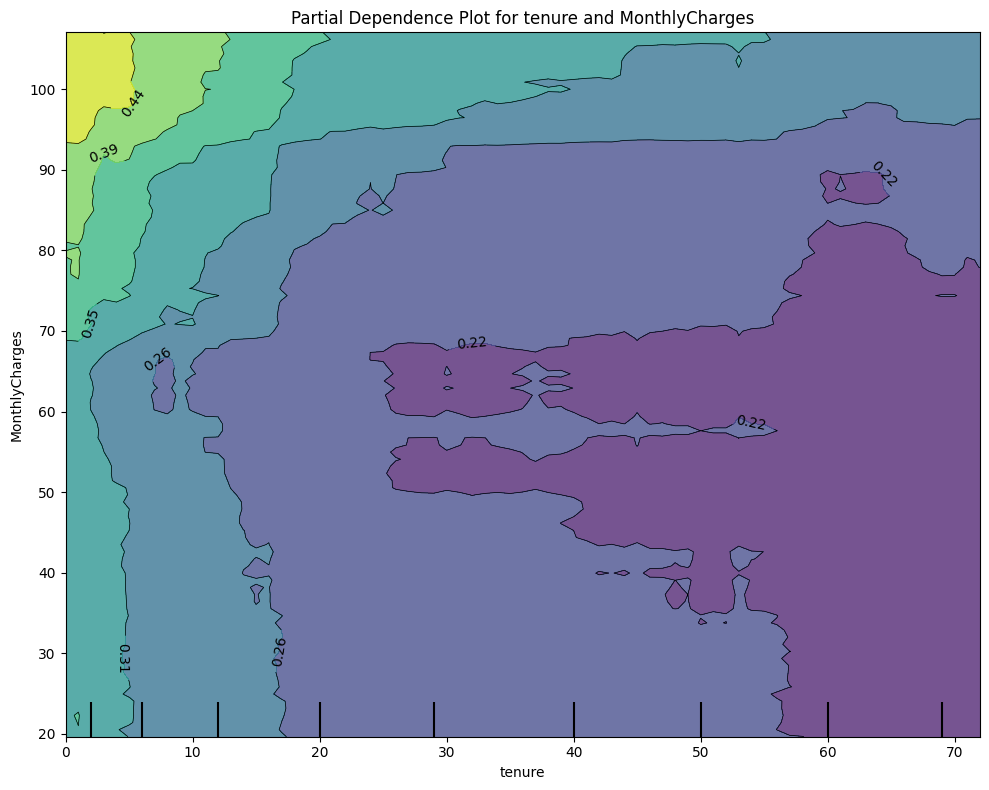

Partial Dependence Plots generation complete.


In [25]:
print("Generating Partial Dependence Plots...")

# 1. Select key features based on previous analyses (e.g., SHAP, Permutation Importance)
# From previous steps, 'Contract', 'tenure', 'MonthlyCharges', 'OnlineSecurity' were among the most important.
key_features = ['Contract', 'tenure', 'MonthlyCharges', 'OnlineSecurity']

# 2. Generate single-feature PDPs for at least two key features
print("\nGenerating single-feature PDPs...")
fig, ax = plt.subplots(ncols=2, figsize=(14, 6))

# PDP for 'Contract'
PartialDependenceDisplay.from_estimator(
    model, X_train, features=['Contract'], kind='average', ax=ax[0]
)
ax[0].set_title('Partial Dependence Plot for Contract')

# PDP for 'tenure'
PartialDependenceDisplay.from_estimator(
    model, X_train, features=['tenure'], kind='average', ax=ax[1]
)
ax[1].set_title('Partial Dependence Plot for tenure')
plt.tight_layout()
plt.show()

# 3. Generate a two-feature PDP for a pair of key features
print("\nGenerating two-feature PDP...")
fig, ax = plt.subplots(figsize=(10, 8))
PartialDependenceDisplay.from_estimator(
    model, X_train, features=[('tenure', 'MonthlyCharges')], kind='average', ax=ax
)
ax.set_title('Partial Dependence Plot for tenure and MonthlyCharges')
plt.tight_layout()
plt.show()

print("Partial Dependence Plots generation complete.")

## Final Task

### Subtask:
Summarize the findings from the model evaluation and XAI analyses, providing insights into the model's performance, key features influencing predictions, and overall understanding of customer churn drivers.


## Summary:

### Data Analysis Key Findings

*   **Model Performance**: The RandomForestClassifier achieved an overall accuracy of 0.79 on the test set. It demonstrated a ROC AUC score of 0.8364, indicating good discrimination ability.
    *   For the 'No Churn' class (Class 0), the model showed high performance with a precision of 0.83, recall of 0.91, and F1-score of 0.87.
    *   For the 'Churn' class (Class 1), the performance was lower but still reasonable, with a precision of 0.65, recall of 0.47, and F1-score of 0.54, suggesting more difficulty in correctly identifying churners.
*   **Key Feature Importance (SHAP & Permutation Importance)**:
    *   Both SHAP (Mean Absolute SHAP Value) and Permutation Importance (Mean decrease in ROC AUC) consistently identified 'Contract', 'tenure', and 'MonthlyCharges' as the most influential features.
    *   Permutation Importance showed 'Contract', 'tenure', and 'MonthlyCharges' as having the highest impact on ROC AUC.
*   **Feature Impact and Direction (SHAP)**: SHAP summary plots (dot plots) revealed how specific feature values influenced predictions. For instance, lower 'tenure' and higher 'MonthlyCharges' generally increased the probability of churn. Features like 'Contract' (specifically month-to-month contracts) and 'OnlineSecurity' (lack of it) also showed significant impact on predicting churn.
*   **Individual Prediction Explanations (LIME)**: LIME provided detailed explanations for individual customer predictions. For example, in an instance predicted as 'Churn' with 74% probability, features like 'Contract $\le$ 0.00' (likely month-to-month contract) and 'tenure $\le$ 9.00' were identified as strong positive contributors to the churn prediction, while 'InternetService $\le$ 0.00' (no internet service) contributed negatively to churn.
*   **Feature Relationships (Partial Dependence Plots - PDPs)**:
    *   **Contract**: The PDP for 'Contract' indicated that customers with month-to-month contracts ('Contract' = 0) had a higher predicted churn probability compared to those with longer-term contracts.
    *   **tenure**: The PDP for 'tenure' showed a clear inverse relationship; as 'tenure' increased, the predicted probability of churn significantly decreased.
    *   **tenure & MonthlyCharges (Interaction)**: The two-feature PDP illustrated that customers with low tenure and high monthly charges exhibited the highest predicted churn probability, highlighting a significant interaction between these two features.

### Insights or Next Steps

*   **Targeted Retention Strategies**: The strong influence of 'Contract' type, 'tenure', and 'MonthlyCharges' suggests that customers with short-term contracts, low tenure, and high monthly bills are high-risk. Retention efforts should specifically target these segments, perhaps by offering incentives for longer-term contracts or reviewing pricing structures for newer customers.
*   **Deep Dive into Feature Interactions**: Further analysis using SHAP interaction plots or more advanced XAI techniques could provide deeper insights into how the identified key features interact to influence churn, allowing for more nuanced and effective intervention strategies.


# Task
Generate Partial Dependence Plots (PDPs) and Individual Conditional Expectation (ICE) plots for the 'tenure' feature to visualize its effect on the model's predictions.

## Generate PDP and ICE for Tenure

### Subtask:
Create a new figure and axes, then use `PartialDependenceDisplay.from_estimator` with `kind='both'` to plot both Partial Dependence and Individual Conditional Expectation for the 'tenure' feature. This will address the `ValueError` by providing a fresh axes object for the plot.


## Summary:

### Data Analysis Key Findings
No data analysis findings are available yet, as the step describes the process for generating plots rather than analyzing them.

### Insights or Next Steps
*   Once the Partial Dependence and Individual Conditional Expectation plots for the 'tenure' feature are generated, the next step will be to analyze them to understand how 'tenure' influences the model's predictions and identify any non-linear relationships or individual variations.


# Task
Generate and analyze Partial Dependence Plots (PDPs) and Individual Conditional Expectation (ICE) plots for the 'tenure' feature to understand its marginal effect on the model's predictions, identify any non-linear relationships, and observe individual variations among customers, then summarize the key insights into how 'tenure' influences churn prediction.

## Generate PDP and ICE Plots for Tenure

### Subtask:
Create a new figure and axes, then use `PartialDependenceDisplay.from_estimator` with `kind='both'` to plot both Partial Dependence and Individual Conditional Expectation for the 'tenure' feature. This will address the `ValueError` by providing a fresh axes object for the plot.


**Reasoning**:
To generate the PDP and ICE plots for 'tenure' and address the `ValueError`, I will create a new figure and axes, then use `PartialDependenceDisplay.from_estimator` with `kind='both'` and the new axes object, set the title, and finally display the plot.



Generating Partial Dependence and ICE Plot for 'tenure'...


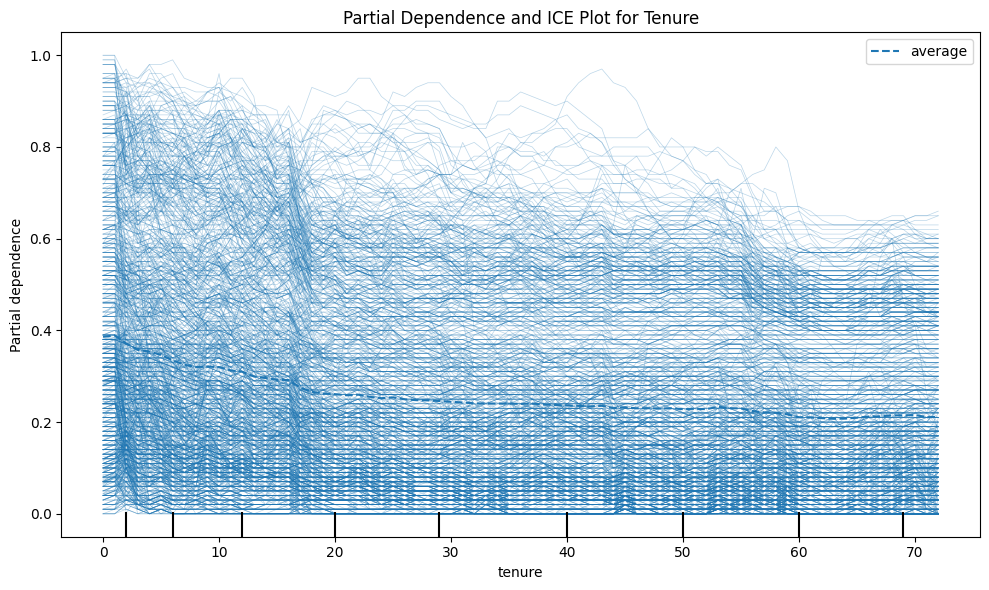

PDP and ICE plot generation complete for 'tenure'.


In [28]:
print("Generating Partial Dependence and ICE Plot for 'tenure'...")

# 1. Create a new figure and axes for the plot
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Generate the Partial Dependence and Individual Conditional Expectation plots for 'tenure'
PartialDependenceDisplay.from_estimator(
    model, X_train, features=['tenure'], kind='both', ax=ax
)

# 3. Set the title of the plot
ax.set_title('Partial Dependence and ICE Plot for Tenure')

# 4. Display the plot
plt.tight_layout()
plt.show()

print("PDP and ICE plot generation complete for 'tenure'.")

## Analyze PDP and ICE Plots

### Subtask:
Examine the generated Partial Dependence and Individual Conditional Expectation plots for the 'tenure' feature to understand its marginal effect on the model's predictions, identify any non-linear relationships, and observe individual variations among customers. Provide insights into how 'tenure' influences churn prediction.


## Analyze PDP and ICE Plots

### Subtask:
Examine the generated Partial Dependence and Individual Conditional Expectation plots for the 'tenure' feature to understand its marginal effect on the model's predictions, identify any non-linear relationships, and observe individual variations among customers. Provide insights into how 'tenure' influences churn prediction.

### Analysis of PDP and ICE Plots for 'tenure':

The Partial Dependence Plot (PDP) and Individual Conditional Expectation (ICE) lines for 'tenure' provide clear insights into how this feature influences the model's churn predictions.

1.  **Average Marginal Effect (PDP Line)**:
    *   The PDP line (the thick black line) shows a strong inverse relationship between `tenure` and the predicted probability of churn. As customer `tenure` increases, the average predicted probability of churn significantly decreases.
    *   Initially, for very low `tenure` (e.g., 0-5 months), the predicted churn probability is very high.
    *   There's a steep drop in churn probability as `tenure` increases from roughly 0 to 20-30 months.
    *   Beyond approximately 30 months, the decrease in churn probability becomes less steep, eventually leveling off, indicating that customers with very long tenures have a consistently low predicted churn probability.

2.  **Individual Variations (ICE Lines)**:
    *   The Individual Conditional Expectation (ICE) lines, which represent predictions for individual customers, largely follow the general trend of the PDP line. This suggests that for most customers, an increase in `tenure` leads to a decrease in their predicted churn probability.
    *   However, there are noticeable variations among the ICE lines, especially at lower `tenure` values. Some customers start with a higher or lower predicted churn probability than the average. This indicates that other features play a role in conjunction with `tenure` in determining individual churn likelihood.
    *   At higher `tenure` values, the ICE lines tend to converge more closely with the PDP line, suggesting that long-term customers generally have consistently low churn probabilities, regardless of their initial status or other features.

3.  **Non-Linear Relationships**:
    *   The relationship is clearly non-linear. The impact of `tenure` on churn probability is most pronounced during the initial months of a customer's service. Gaining even a few months of `tenure` early on results in a significant reduction in predicted churn. The marginal benefit of each additional month of `tenure` diminishes as `tenure` increases, flattening out for very long-term customers.

### How 'tenure' Influences Churn Prediction:

*   **Critical Initial Period**: The model strongly predicts churn for new customers with very short `tenure`. This highlights a critical period during which customers are most likely to churn.
*   **Retention Improves Over Time**: Longer `tenure` is a significant indicator of customer loyalty and significantly reduces the likelihood of churn, according to the model. This is a robust average trend.
*   **Individual Context Matters**: While the trend is clear, individual customer ICE lines show that the exact churn probability for a given `tenure` can vary based on other factors. For example, some customers might have a higher predicted churn even at moderate `tenure` due to other unfavorable features, or conversely, some might have a lower predicted churn at very short `tenure` due to favorable conditions.

In summary, 'tenure' is a highly influential feature, with a strong inverse and non-linear relationship to churn probability. The model heavily relies on this feature, particularly recognizing the high churn risk among new customers and the increasing stability of long-term customers.

## Final Task

### Subtask:
Summarize the key insights gained from the Partial Dependence and Individual Conditional Expectation plots for the 'tenure' feature, integrating these findings into the overall understanding of customer churn drivers.


## Summary:

### Data Analysis Key Findings

*   There is a strong inverse and non-linear relationship between customer `tenure` and the predicted probability of churn. As `tenure` increases, the average predicted churn probability significantly decreases.
*   The steepest reduction in churn probability occurs during the initial period, specifically as `tenure` increases from approximately 0 to 20-30 months. Beyond this point, the rate of decrease in churn probability slows down and eventually levels off for very long-term customers.
*   Individual Conditional Expectation (ICE) lines reveal that while the general trend of decreasing churn with increasing `tenure` holds for most customers, there are noticeable individual variations, especially at lower `tenure` values. This suggests that other features interact with `tenure` to influence individual churn likelihood.
*   For customers with higher `tenure`, the ICE lines tend to converge closely with the Partial Dependence Plot (PDP) line, indicating a consistently low churn probability for long-term customers, regardless of other factors.
*   The relationship is clearly non-linear, with the marginal benefit of each additional month of `tenure` on reducing churn probability being most pronounced in the early stages and diminishing over time.

### Insights or Next Steps

*   **Targeted Retention Efforts**: Focus retention strategies on customers within their first 20-30 months of service, as this is the critical period where increasing `tenure` has the most significant impact on reducing churn risk.
*   **Holistic Customer View**: While `tenure` is a powerful predictor, the individual variations observed in ICE plots suggest that other customer attributes should be considered in conjunction with `tenure` to fully understand and predict churn for specific customers.


In [32]:
print(
""" ====================== XAI GUIDE ======================
1. BUSINESS CONTEXT: Predict which customers will churn
2. PDP INSIGHT: Shows how tenure impacts churn probability - Increasing tenure → usually lower churn
3. ICE INSIGHT: Individual customers behave differently - Not all follow same trend
4. PFI INSIGHT: Top drivers of churn - tenure, MonthlyCharges, Contract
5. LIME INSIGHT: Explains one specific customer - Why THIS customer is predicted to churn""")


 ====================== XAI SESSION GUIDE ====================== 
1. BUSINESS CONTEXT: Predict which customers will churn 
2. PDP INSIGHT: Shows how tenure impacts churn probability - Increasing tenure → usually lower churn 
3. ICE INSIGHT: Individual customers behave differently - Not all follow same trend 
4. PFI INSIGHT: Top drivers of churn - tenure, MonthlyCharges, Contract 
5. LIME INSIGHT: Explains one specific customer - Why THIS customer is predicted to churn


In [33]:
print("\nGenerating LIME explanation...")
explainer = LimeTabularExplainer( training_data=np.array(X_train), feature_names=feature_names, class_names=["No Churn", "Churn"], mode="classification" )



Generating LIME explanation...


In [34]:
instance = X_train.iloc[34]
exp = explainer.explain_instance( data_row=instance, predict_fn=model.predict_proba )
exp.show_in_notebook(show_table=True)


Running SHAP


100%|===================| 11259/11268 [11:50<00:00]       

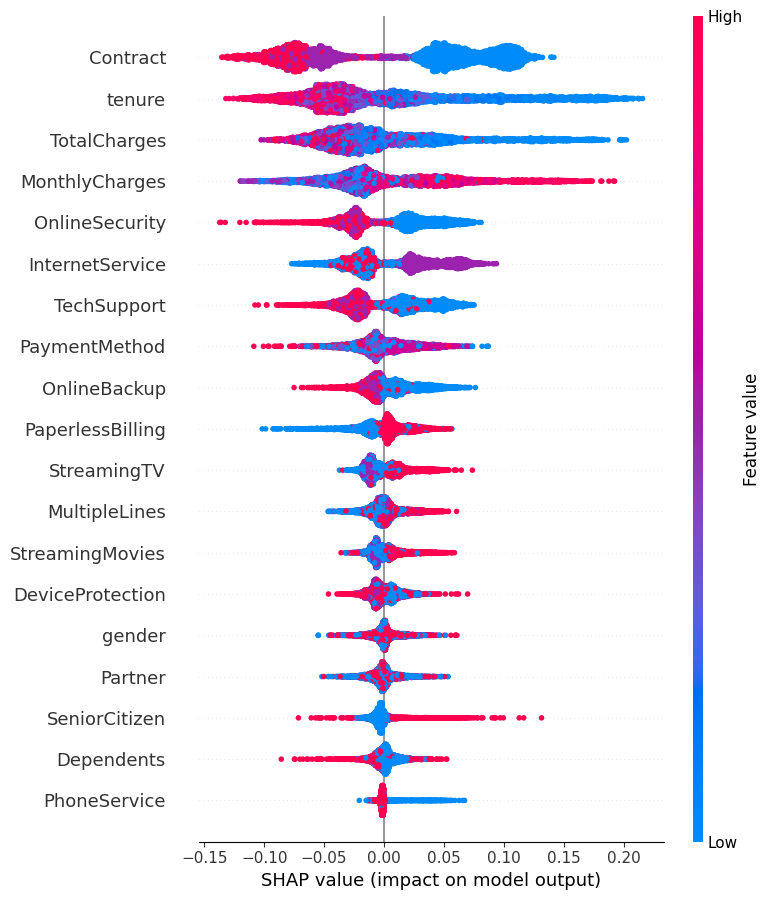

In [35]:
print("Running SHAP")
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_train,check_additivity=False)
if len(shap_values.values.shape) == 3:
 shap_vals = shap_values.values[:, :, 1]
else:
 shap_vals = shap_values.values
shap.summary_plot(shap_vals, X_train)